# Satellite–ground collocation sensitivity

Reproduce quantitative radius tradeoffs in published OCO-2, OCO-3 and TROPOMI comparisons; build and test geometric/time filtering code.

**Data provenance and limitations:** Analysis uses published summary tables. No new raw-satellite validation or mission-specific Level-0 to Level-2 processing is claimed. Matching code still needs mission QC, averaging kernels and prior harmonisation for a real validation campaign.

This notebook runs the repository analysis and displays its saved results.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
from analysis import run
metrics = run()
print(json.dumps(metrics, indent=2))

{
  "published_summary_rows": 23,
  "source_tables": [
    "B1",
    "B2",
    "B3"
  ],
  "raw_satellite_validation_performed": false,
  "selected_radius_results": [
    {
      "mission": "OCO-2 v10r",
      "gas": "CO2",
      "unit": "ppm",
      "source_table": "B1",
      "radius_km": 300,
      "comparison_days": 8,
      "satellite_retrievals": 1725,
      "mean_difference": -1.2,
      "sd_difference": 1.05
    },
    {
      "mission": "OCO-3 v10.4r",
      "gas": "CO2",
      "unit": "ppm",
      "source_table": "B1",
      "radius_km": 300,
      "comparison_days": 4,
      "satellite_retrievals": 324,
      "mean_difference": -1.15,
      "sd_difference": 1.61
    },
    {
      "mission": "TROPOMI",
      "gas": "CH4",
      "unit": "ppb",
      "source_table": "B2",
      "radius_km": 300,
      "comparison_days": 8,
      "satellite_retrievals": 1674,
      "mean_difference": -8.39,
      "sd_difference": 10.5
    },
    {
      "mission": "TROPOMI",
      "gas": "CO",


## Spatial/time matching: controlled demonstration

The following coordinates and times are constructed test data, separate from the published summary dataset. One point is close in both space and time; the others fail one criterion.

In [2]:
from analysis import collocate
synthetic_soundings = pd.DataFrame({'latitude':[0.0,0.0,0.0], 'longitude':[0.1,3.0,0.1], 'time':['2020-01-01T10:30Z','2020-01-01T10:30Z','2020-01-01T15:30Z']})
matched = collocate(synthetic_soundings, 0.0, 0.0, '2020-01-01T10:30Z', radius_km=50, time_hours=2)
display(matched)
assert len(matched) == 1

,latitude,longitude,time,distance_km,time_difference_hours
0,0.0,0.1,2020-01-01T10:30Z,11.119508,0.0


radius_tradeoffs.png


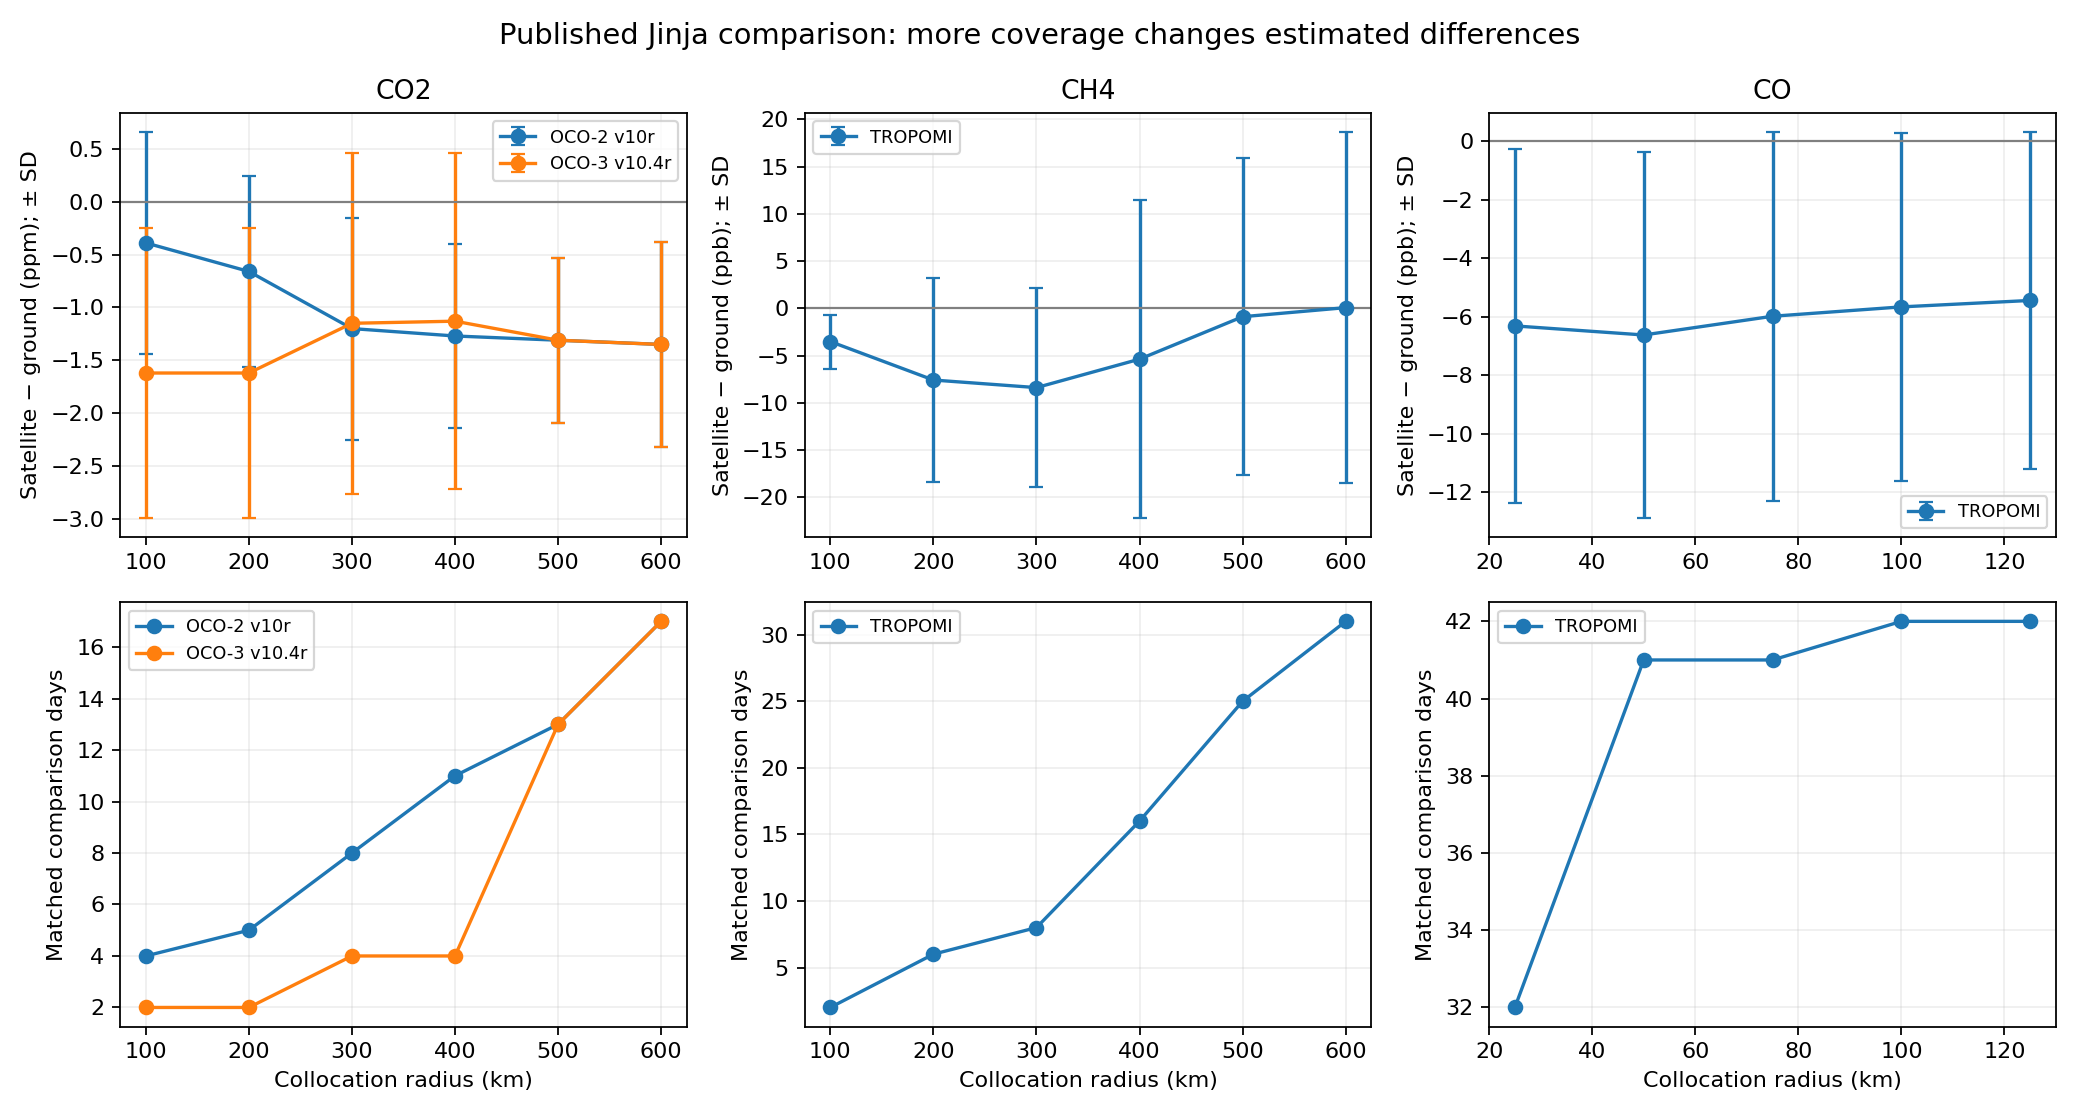

In [3]:
for path in sorted(Path('results').glob('*.png')):
    print(path.name)
    display(Image(filename=str(path)))

In [4]:
for path in sorted(Path('results').glob('*.csv')):
    print(path.name)
    display(pd.read_csv(path).head(10))

paper_selected_radii.csv
radius_sensitivity_summary.csv


,mission,gas,unit,source_table,radius_km,comparison_days,satellite_retrievals,mean_difference,sd_difference
0,OCO-2 v10r,CO2,ppm,B1,300,8,1725,-1.20,1.05
1,OCO-3 v10.4r,CO2,ppm,B1,300,4,324,-1.15,1.61
2,TROPOMI,CH4,ppb,B2,300,8,1674,-8.39,10.50
3,TROPOMI,CO,ppb,B3,50,41,4738,-6.62,6.25


,mission,gas,unit,radius_min_km,radius_max_km,days_min,days_max,change_in_mean_difference
0,OCO-2 v10r,CO2,ppm,100,600,4,17,-0.96
1,OCO-3 v10.4r,CO2,ppm,100,600,2,17,0.27
2,TROPOMI,CH4,ppb,100,600,2,31,3.59
3,TROPOMI,CO,ppb,25,125,32,42,0.87


## Interpretation and next steps

Analysis uses published summary tables. No new raw-satellite validation or mission-specific Level-0 to Level-2 processing is claimed. Matching code still needs mission QC, averaging kernels and prior harmonisation for a real validation campaign.

Use `results/metrics.json` and the displayed tables to report actual findings. Consult `REVIEW_GUIDE.md` before using the CV wording: **Reproduced published satellite–EM27/SUN collocation-radius sensitivity results for CO2, CH4 and CO, and tested reusable spatial/temporal matching functions.**

### Observed result

Reproduced **23 rows** from the published Tables B1–B3. At 300 km, the published OCO-2 difference is **−1.20 ± 1.05 ppm** across 8 comparison days; OCO-3 is **−1.15 ± 1.61 ppm** across 4 days. At 50 km, the published TROPOMI CO difference is **−6.62 ± 6.25 ppb** across 41 days. Signs are satellite minus ground and ± values are SD, not confidence intervals. These are the paper’s results, not new independently retrieved measurements.